# DELTA DIY MRI Workshop — Designing Saturation and Refocusing Pulses

*Session: 40 minutes. Design exercise.*

Two pulses, two different jobs, two different failure modes:

- A **saturation pulse** drives Mz to zero across a band and leaves it there. Used to null a
  region before you image, or to prepare contrast. Its job is *destroying* magnetisation
  predictably.
- A **refocusing pulse** inverts the transverse phase so dephased spins re-align into an echo.
  This is the 180° in the spin echo you have already been running. Its job is *preserving*
  magnetisation while reversing its phase.

They are both nominally simple flip angles — 90° and 180° — but "nominally" is doing a lot of
work. A real pulse has a duration, a bandwidth, a peak amplitude your amplifier has to reach,
and a tolerance to the B1 your coil actually delivers rather than the one you assumed. Those
are the design axes, and they trade against each other:

```
        sharper profile  <-->  longer pulse  or  higher peak B1
        more B1-robust   <-->  longer pulse  and  more RF energy
```

You will design both pulses with **PulPy**, simulate what they do with the Shinnar–Le Roux
forward model, check them against the scanner's real RF limit, discover where each one breaks,
and export a design to a `.seq` file MRI4ALL can play.

**Prerequisites:** `01_setup_environment.ipynb`, and `03_MRI4all_seq_runner.ipynb` for the
`.seq` toolchain. No scanner needed. Uses `pulpy`, `pypulseq`, `numpy`, `matplotlib`.

## Cell 1 — Environment

Same console setup as notebooks 03 and 04 (append `console/` so the installed PyPulseq wins
over the vendored copy), plus PulPy.

The two PulPy pieces used throughout:

- `pulpy.rf.slr.dzrf` — Shinnar–Le Roux pulse design. Its `ptype` argument names the job
  directly: `'sat'` for saturation, `'se'` for spin-echo refocusing, and also `'ex'`
  (excitation) and `'inv'` (inversion).
- `pulpy.sim.abrm` — forward SLR simulation. Returns the Cayley–Klein parameters `(a, b)`,
  from which every profile you care about follows.

In [3]:
# Cell 1 — Environment and imports

import os
import sys
from pathlib import Path

print("Cell 1 — Environment")
print("--------------------")

here = Path.cwd().resolve()
repo_root = None
for candidate in [here, *here.parents]:
    if (candidate / "console" / "external" / "flocra_pulseq").is_dir():
        repo_root = candidate
        break
if repo_root is None:
    raise RuntimeError("Run this notebook from console/notebooks/ inside the repository.")

console_dir = repo_root / "console"
work_dir = Path.cwd() / "pulse_design_output"
work_dir.mkdir(exist_ok=True)
os.environ.setdefault("MRI4ALL_BASE", str(work_dir / "mri4all"))
(Path(os.environ["MRI4ALL_BASE"]) / "logs").mkdir(parents=True, exist_ok=True)

if str(console_dir) not in sys.path:
    sys.path.append(str(console_dir))      # APPEND -- see notebook 03, Cell 1

import numpy as np
import matplotlib.pyplot as plt
import pypulseq as pp

from pulpy.rf import slr, adiabatic
import pulpy.sim as sim

from importlib.metadata import version

print("pulpy    :", version("pulpy"))
print("pypulseq :", Path(pp.__file__).parent)
print("\nSLR pulse types available via dzrf(ptype=...):")
print("   'sat' saturation | 'se' spin-echo refocusing | 'ex' excitation | 'inv' inversion")
print("\nPASS: environment ready.")

Cell 1 — Environment
--------------------
pulpy    : 1.8.8
pypulseq : /home/jonathanmartin/anaconda3/envs/adelpha/lib/python3.11/site-packages/pypulseq

SLR pulse types available via dzrf(ptype=...):
   'sat' saturation | 'se' spin-echo refocusing | 'ex' excitation | 'inv' inversion

PASS: environment ready.


/home/jonathanmartin/anaconda3/envs/adelpha/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cell 2 — The budget you are designing against

A pulse design is only useful if the scanner can play it. Two hard limits:

**Peak B1.** `RF_MAX` is the RF amplitude at DAC full scale (notebook 03, Cell 2). Exceed it
and the waveform clips — the flip angle is then wrong in a way no calibration fixes.

PulPy returns RF in **radians per sample**. Two conversions carry you between that and the
scanner's world, and both are worth committing to memory:

```
flip angle (rad) = sum(rf)                  # on-resonance flip
peak B1 (Hz)     = max|rf| / (2*pi*dt)      # dt = pulse duration / number of samples
```

The second one contains the whole design tension: **peak B1 scales as 1/duration.** Halve the
pulse duration and you double the amplitude you need. A 180° needs twice the *area* of a 90°,
so it needs **at least** twice the peak B1 at equal duration — and usually more, because the
two designs do not have the same shape. Cell 4 measures the actual ratio rather than assuming
it.

**Time.** Every microsecond of pulse is a microsecond not spent acquiring, and it sits inside
TE. Long, robust pulses are not free.

In [4]:
# Cell 2 — Read the RF limit and set up unit conversions

print("Cell 2 — Design budget")
print("----------------------")

import logging

logging.disable(logging.WARNING)
try:
    import external.seq.adjustments_acq.config as cfg
    RF_MAX_HZ = float(cfg.RF_MAX)
    LARMOR_MHZ = float(cfg.LARMOR_FREQ)
    source = "console adjustment config"
except Exception as exc:
    RF_MAX_HZ, LARMOR_MHZ = 5.0e3, 15.52
    source = f"fallback ({type(exc).__name__})"
finally:
    logging.disable(logging.NOTSET)


def flip_angle_deg(rf):
    """On-resonance flip angle of a PulPy waveform, in degrees."""
    return float(np.real(np.sum(rf))) * 180 / np.pi


def peak_b1_hz(rf, duration_s):
    """Peak B1 amplitude in Hz for a PulPy waveform played over duration_s."""
    dt = duration_s / len(rf)
    return float(np.abs(rf).max() / (2 * np.pi * dt))


def feasible(rf, duration_s):
    return peak_b1_hz(rf, duration_s) <= RF_MAX_HZ


print("Calibration source:", source)
print(f"  Larmor frequency : {LARMOR_MHZ:.4f} MHz")
print(f"  RF_MAX           : {RF_MAX_HZ:.0f} Hz   <-- peak B1 must stay under this")
print()
print("Rule of thumb, for a fixed pulse shape:")
for dur_us in (500, 1000, 2000, 4000):
    print(f"    {dur_us:5d} us pulse  ->  peak B1 scales as 1/duration")
print()
print("A 180 needs twice the AREA of a 90 -- so at least twice the peak B1, often more.")

Cell 2 — Design budget
----------------------
Calibration source: console adjustment config
  Larmor frequency : 15.5200 MHz
  RF_MAX           : 10000 Hz   <-- peak B1 must stay under this

Rule of thumb, for a fixed pulse shape:
      500 us pulse  ->  peak B1 scales as 1/duration
     1000 us pulse  ->  peak B1 scales as 1/duration
     2000 us pulse  ->  peak B1 scales as 1/duration
     4000 us pulse  ->  peak B1 scales as 1/duration

A 180 needs twice the AREA of a 90 -- so at least twice the peak B1, often more.


## Cell 3 — Design a saturation pulse

`dzrf(ptype='sat')` designs a 90° pulse optimised to null Mz across the passband. The knobs:

| Parameter | Effect |
| --- | --- |
| `tb` | time-bandwidth product. Higher = sharper profile edges, but more peak B1 for a given duration |
| `n` | number of samples in the waveform |
| `d1`, `d2` | allowed ripple in the passband and stopband |
| `ftype` | filter design: `'ls'` least-squares, `'pm'` equal-ripple, `'ms'` sinc, `'min'`/`'max'` phase |

The quantity to judge a saturation pulse by is **Mz**, from the SLR parameters:

```
Mz = 1 - 2|b|^2
```

Mz = 0 is perfect saturation, Mz = +1 is untouched, Mz = −1 is fully inverted. **Inversion is
not saturation** — an over-cooked "saturation" pulse that inverts leaves you with signal of
the opposite sign, which is worse than leaving it alone.

Note what a saturation pulse alone does *not* do: it tips magnetisation into the transverse
plane, where it is still perfectly good signal. It only becomes saturation once a **spoiler
gradient** dephases it. Pulse and spoiler are one unit; Cell 8 exports them together.

Cell 3 — Saturation pulse
-------------------------
  samples        : 128
  duration       : 1280 us
  flip angle     : 88.8 deg
  peak B1        : 901.5 Hz   (RF_MAX 10000 Hz)
  feasible       : YES
  Mz at centre   : +0.020   (0 = fully saturated)
  Mz in stopband : +1.000   (+1 = untouched, as it should be)


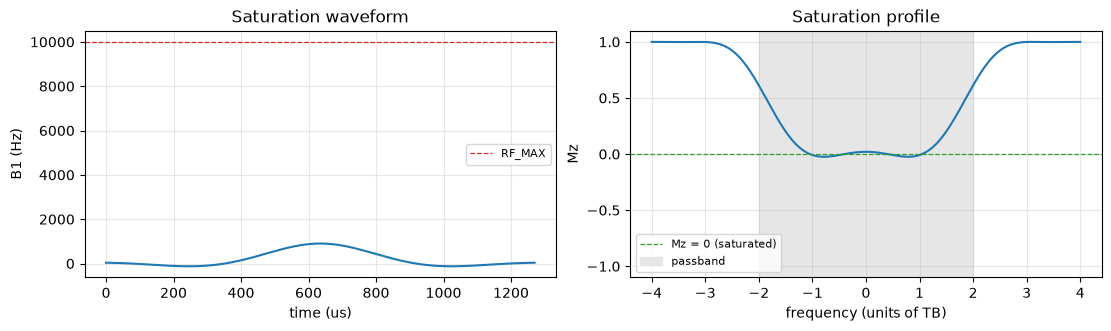

In [5]:
%matplotlib inline

# Cell 3 — Saturation pulse design

print("Cell 3 — Saturation pulse")
print("-------------------------")

N_SAMPLES = 128
TB = 4
DURATION_S = 1.28e-3          # 128 samples x 10 us, on the 1 us RF raster

rf_sat = slr.dzrf(n=N_SAMPLES, tb=TB, ptype="sat", ftype="ls", d1=0.01, d2=0.01)

# Profile: x is in units of the time-bandwidth product (passband edge at |x| = tb/2)
x = np.linspace(-4, 4, 801)
a_sat, b_sat = sim.abrm(rf_sat, x)
mz_sat = 1 - 2 * np.abs(b_sat) ** 2

print(f"  samples        : {len(rf_sat)}")
print(f"  duration       : {DURATION_S*1e6:.0f} us")
print(f"  flip angle     : {flip_angle_deg(rf_sat):.1f} deg")
print(f"  peak B1        : {peak_b1_hz(rf_sat, DURATION_S):.1f} Hz   (RF_MAX {RF_MAX_HZ:.0f} Hz)")
print(f"  feasible       : {'YES' if feasible(rf_sat, DURATION_S) else 'NO -- would clip'}")
print(f"  Mz at centre   : {mz_sat[np.argmin(np.abs(x))]:+.3f}   (0 = fully saturated)")
print(f"  Mz in stopband : {mz_sat[0]:+.3f}   (+1 = untouched, as it should be)")

t_us = np.arange(len(rf_sat)) * DURATION_S / len(rf_sat) * 1e6
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2), constrained_layout=True)
ax[0].plot(t_us, np.real(rf_sat) / (2 * np.pi * (DURATION_S / len(rf_sat))))
ax[0].axhline(RF_MAX_HZ, color="tab:red", ls="--", lw=0.9, label="RF_MAX")
ax[0].set_xlabel("time (us)"); ax[0].set_ylabel("B1 (Hz)")
ax[0].set_title("Saturation waveform"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].plot(x, mz_sat)
ax[1].axhline(0, color="tab:green", ls="--", lw=0.9, label="Mz = 0 (saturated)")
ax[1].axvspan(-TB / 2, TB / 2, color="0.9", zorder=0, label="passband")
ax[1].set_xlabel("frequency (units of TB)"); ax[1].set_ylabel("Mz")
ax[1].set_ylim(-1.1, 1.1); ax[1].set_title("Saturation profile")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.show()

## Cell 4 — Design a refocusing pulse

`dzrf(ptype='se')` designs a 180° optimised as a *refocusing* pulse, which is a different
optimisation from an inversion pulse even though both are nominally 180°. An inversion pulse
cares only about Mz; a refocusing pulse has to invert transverse **phase** cleanly across the
band, and the quantity that measures that is the refocusing efficiency:

```
refocusing efficiency = |b^2|
```

1.0 means every spin in the band is perfectly refocused; 0 means no echo. Design `'inv'`
instead and you get a pulse that inverts Mz beautifully and refocuses less well — the
distinction matters, and PulPy exposes both so you can see it.

Compare the peak B1 with Cell 3. Same duration, same TB, same ripple spec — only the job
changed, and the amplitude requirement rises by **roughly three times**, not the factor of two
the doubled area alone would suggest. The extra comes from the shape: the two filter designs
have different peak-to-area ratios. This is why you measure rather than reason about it.

Note also the flip angles the cells report: about 89° and 161°, not exactly 90° and 180°. That
is not an error. For an SLR pulse the on-resonance flip is `2·asin(|b|)`, and the ripple you
allowed (`d1 = 0.01`) keeps `|b|` just under 1. Tighten `d1` and the flip creeps closer to
nominal, at the cost of a longer or stronger pulse. Cell 6 shows the consequence.

Cell 4 — Refocusing pulse
-------------------------
  flip angle       : 161.3 deg
  peak B1          : 2644.6 Hz   (RF_MAX 10000 Hz)
  feasible         : YES
  refocusing eff.  : 0.974   ('se' design)
  refocusing eff.  : 0.983   ('inv' design, for comparison)
  Mz at centre     : -0.947

Peak B1 vs the saturation pulse: 2.93x
  (doubling the area sets a floor of 2x; the rest is the difference in pulse shape)


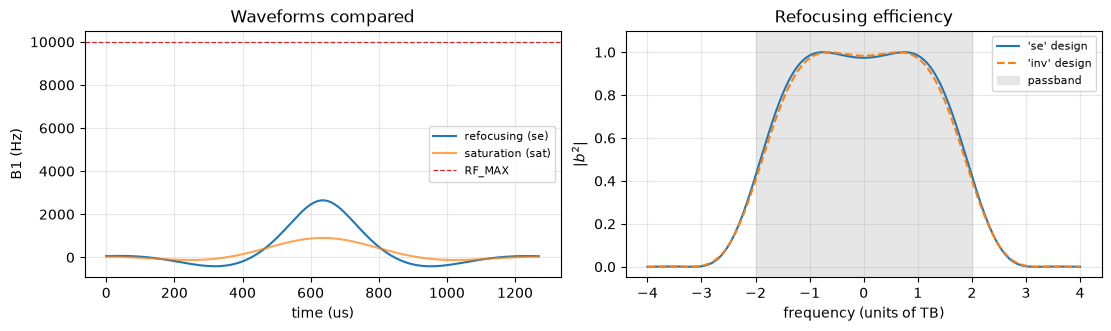

In [6]:
%matplotlib inline

# Cell 4 — Refocusing pulse design

print("Cell 4 — Refocusing pulse")
print("-------------------------")

rf_se = slr.dzrf(n=N_SAMPLES, tb=TB, ptype="se", ftype="ls", d1=0.01, d2=0.01)
rf_inv = slr.dzrf(n=N_SAMPLES, tb=TB, ptype="inv", ftype="ls", d1=0.01, d2=0.01)

a_se, b_se = sim.abrm(rf_se, x)
a_inv, b_inv = sim.abrm(rf_inv, x)
refocus_se = np.abs(1j * b_se ** 2)
refocus_inv = np.abs(1j * b_inv ** 2)
mz_se = 1 - 2 * np.abs(b_se) ** 2

centre = np.argmin(np.abs(x))
print(f"  flip angle       : {flip_angle_deg(rf_se):.1f} deg")
print(f"  peak B1          : {peak_b1_hz(rf_se, DURATION_S):.1f} Hz   (RF_MAX {RF_MAX_HZ:.0f} Hz)")
print(f"  feasible         : {'YES' if feasible(rf_se, DURATION_S) else 'NO -- would clip'}")
print(f"  refocusing eff.  : {refocus_se[centre]:.3f}   ('se' design)")
print(f"  refocusing eff.  : {refocus_inv[centre]:.3f}   ('inv' design, for comparison)")
print(f"  Mz at centre     : {mz_se[centre]:+.3f}")
print()
ratio = peak_b1_hz(rf_se, DURATION_S) / peak_b1_hz(rf_sat, DURATION_S)
print(f"Peak B1 vs the saturation pulse: {ratio:.2f}x")
print("  (doubling the area sets a floor of 2x; the rest is the difference in pulse shape)")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2), constrained_layout=True)
dt = DURATION_S / len(rf_se)
ax[0].plot(t_us, np.real(rf_se) / (2 * np.pi * dt), label="refocusing (se)")
ax[0].plot(t_us, np.real(rf_sat) / (2 * np.pi * dt), label="saturation (sat)", alpha=0.7)
ax[0].axhline(RF_MAX_HZ, color="tab:red", ls="--", lw=0.9, label="RF_MAX")
ax[0].set_xlabel("time (us)"); ax[0].set_ylabel("B1 (Hz)")
ax[0].set_title("Waveforms compared"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].plot(x, refocus_se, label="'se' design")
ax[1].plot(x, refocus_inv, label="'inv' design", ls="--")
ax[1].axvspan(-TB / 2, TB / 2, color="0.9", zorder=0, label="passband")
ax[1].set_xlabel("frequency (units of TB)"); ax[1].set_ylabel("$|b^2|$")
ax[1].set_ylim(-0.05, 1.1); ax[1].set_title("Refocusing efficiency")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.show()

## Cell 5 — The three-way trade

Now make the trade explicit. Sweep time-bandwidth product against pulse duration and ask, for
each combination, whether the peak B1 fits under `RF_MAX`.

The pattern to read out of the table: **sharpness costs either time or amplitude, and you only
get to choose which.** Every entry marked infeasible is a design that looks fine on paper and
clips on the scanner.

In [7]:
# Cell 5 — Feasibility map: TB vs duration vs RF_MAX

print("Cell 5 — What actually fits under RF_MAX")
print("----------------------------------------")

durations_us = [500, 1000, 2000, 4000]
tb_values = [2, 4, 6, 8]

for ptype, label in (("sat", "SATURATION (90)"), ("se", "REFOCUSING (180)")):
    print(f"\n{label} -- peak B1 in Hz, RF_MAX = {RF_MAX_HZ:.0f} Hz")
    header = "   TB \\ dur " + "".join(f"{d:>10d} us" for d in durations_us)
    print(header)
    print("   " + "-" * (len(header) - 3))
    for tb in tb_values:
        rf_i = slr.dzrf(n=N_SAMPLES, tb=tb, ptype=ptype, ftype="ls", d1=0.01, d2=0.01)
        row = f"   {tb:>3d}      "
        for dur_us in durations_us:
            b1 = peak_b1_hz(rf_i, dur_us * 1e-6)
            flag = " " if b1 <= RF_MAX_HZ else "*"
            row += f"{b1:>10.0f}{flag} "
        print(row)

print("\n  * = exceeds RF_MAX; the amplifier would clip and the flip angle would be wrong.")
print("\nRead it as: to sharpen the profile (higher TB) at fixed duration you need more")
print("amplitude; if you have not got the amplitude, you must lengthen the pulse instead.")

Cell 5 — What actually fits under RF_MAX
----------------------------------------

SATURATION (90) -- peak B1 in Hz, RF_MAX = 10000 Hz
   TB \ dur        500 us      1000 us      2000 us      4000 us
   -------------------------------------------------------------
     2             998         499         250         125  
     4            2308        1154         577         288  
     6            3456        1728         864         432  
     8            4571        2286        1143         571  

REFOCUSING (180) -- peak B1 in Hz, RF_MAX = 10000 Hz
   TB \ dur        500 us      1000 us      2000 us      4000 us
   -------------------------------------------------------------
     2            2260        1130         565         283  
     4            6770        3385        1693         846  
     6           10799*       5399        2700        1350  
     8           14500*       7250        3625        1813  

  * = exceeds RF_MAX; the amplifier would clip and the flip an

## Cell 6 — Where these pulses break: B1 error

Everything so far assumed the coil delivers exactly the B1 you asked for. It does not. Coil
loading changes with the sample, the transmit calibration drifts, and B1 varies across the
sample — a solenoid or surface coil at low field is not homogeneous.

So the question that decides whether a design survives contact with hardware is: **what
happens when the actual B1 is 20% low, or 30% high?** Simulate it by scaling the waveform.

Watch the two pulse types fail differently, because this is the crux of the session:

- **Saturation fails in both directions, and asymmetrically badly.** Too little B1 leaves
  residual Mz — incomplete saturation, signal you meant to remove. Too much pushes past 90°
  toward inversion, giving you Mz of the *opposite sign*. There is exactly one correct
  amplitude and no margin on either side.
- **Refocusing is more forgiving near the top** — the efficiency curve is flat-ish around the
  nominal value — but it collapses once B1 is far off, and in a multi-echo train each pulse
  compounds the last one's error.

One detail to look for in the table: refocusing efficiency peaks slightly **above** a B1 scale
of 1.0, not at it. That follows from the 161° flip noted in Cell 4 — the designed pulse
under-flips a little, so a touch more B1 lands nearer a true 180°. It is a real effect you can
exploit, and a reminder that "nominal" is a property of the design, not of the physics.

Cell 6 — B1 robustness
----------------------
   B1 scale    sat: Mz   se: |b^2|
  --------------------------------
       0.60     +0.598       0.559
       0.80     +0.324       0.815
       0.90     +0.175       0.910
       1.00     +0.020       0.974
       1.10     -0.134       0.999
       1.20     -0.286       0.986
       1.40     -0.564       0.849

Over a +/-10% B1 error:
  saturation leaves |Mz| up to 0.136  (0 would be perfect)
  refocusing efficiency drops to 0.929


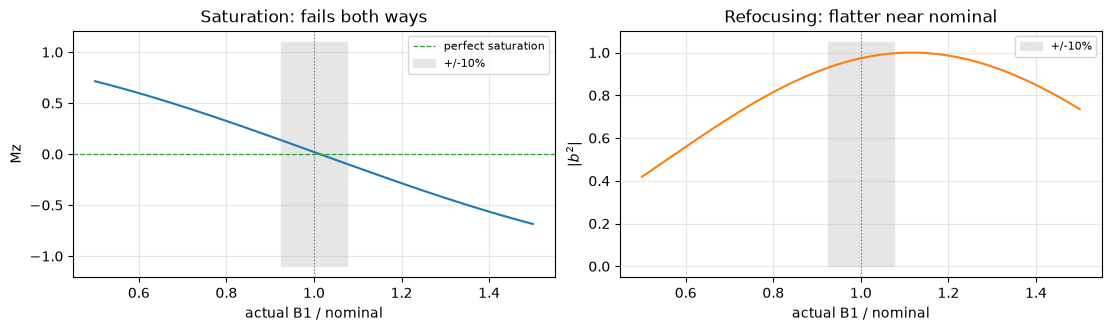

In [8]:
%matplotlib inline

# Cell 6 — Sensitivity to B1 scaling error

print("Cell 6 — B1 robustness")
print("----------------------")

b1_scales = np.linspace(0.5, 1.5, 41)
centre_only = np.array([0.0])

mz_vs_b1, refocus_vs_b1 = [], []
for s in b1_scales:
    _, b_s = sim.abrm(rf_sat * s, centre_only)
    mz_vs_b1.append((1 - 2 * np.abs(b_s) ** 2)[0])
    _, b_r = sim.abrm(rf_se * s, centre_only)
    refocus_vs_b1.append(np.abs(1j * b_r ** 2)[0])

mz_vs_b1 = np.array(mz_vs_b1)
refocus_vs_b1 = np.array(refocus_vs_b1)

print(f"  {'B1 scale':>9s} {'sat: Mz':>10s} {'se: |b^2|':>11s}")
print("  " + "-" * 32)
for s in (0.6, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4):
    i = int(np.argmin(np.abs(b1_scales - s)))
    print(f"  {b1_scales[i]:9.2f} {mz_vs_b1[i]:+10.3f} {refocus_vs_b1[i]:11.3f}")

within10 = (b1_scales > 0.9) & (b1_scales < 1.1)
print()
print(f"Over a +/-10% B1 error:")
print(f"  saturation leaves |Mz| up to {np.abs(mz_vs_b1[within10]).max():.3f}  (0 would be perfect)")
print(f"  refocusing efficiency drops to {refocus_vs_b1[within10].min():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2), constrained_layout=True)
ax[0].plot(b1_scales, mz_vs_b1)
ax[0].axhline(0, color="tab:green", ls="--", lw=0.9, label="perfect saturation")
ax[0].axvline(1.0, color="0.5", ls=":", lw=0.9)
ax[0].fill_between(b1_scales, -1.1, 1.1, where=within10, color="0.9", zorder=0, label="+/-10%")
ax[0].set_xlabel("actual B1 / nominal"); ax[0].set_ylabel("Mz")
ax[0].set_title("Saturation: fails both ways"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].plot(b1_scales, refocus_vs_b1, color="tab:orange")
ax[1].axvline(1.0, color="0.5", ls=":", lw=0.9)
ax[1].fill_between(b1_scales, 0, 1.05, where=within10, color="0.9", zorder=0, label="+/-10%")
ax[1].set_xlabel("actual B1 / nominal"); ax[1].set_ylabel("$|b^2|$")
ax[1].set_title("Refocusing: flatter near nominal"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.show()

## Cell 7 — The adiabatic answer, and what it costs

If B1 accuracy is the problem, an **adiabatic** pulse is the standard answer. Rather than
relying on a calibrated amplitude, it sweeps frequency so the effective field rotates slowly
enough that the magnetisation follows it — and once you are above a threshold amplitude, the
result stops depending on B1 almost entirely.

PulPy provides `adiabatic.bir4` (B1-Insensitive Rotation), among others. BIR-4 returns an
**AM waveform and an FM waveform** rather than a single complex pulse, so combine them:

```python
a_am, om = adiabatic.bir4(n, beta, kappa, theta, dw0)
rf = a_am * np.exp(1j * np.cumsum(om) * dt)      # FM -> phase
```

The cell sweeps peak amplitude to show the **threshold** explicitly. Below it, the adiabatic
condition is violated and the pulse is no better than anything else. Above it, the response is
flat across a B1 range that would wreck the SLR pulses from Cell 6.

The cost is real and worth stating: adiabatic pulses are **longer** and deposit **more RF
energy** for the same nominal flip. At low field the energy is rarely the binding constraint,
which is precisely why they are attractive here.

Cell 7 — Adiabatic (BIR-4)
--------------------------
  Duration 4000 us, 1024 samples. RF_MAX = 10000 Hz.

    peak B1  feasible     0.6    0.8    1.0    1.2    1.4
  ------------------------------------------------------
      250 Hz       yes    0.23   0.37   0.51   0.64   0.75
      500 Hz       yes    0.64   0.83   0.94   0.98   0.99
     1000 Hz       yes    0.98   1.00   1.00   1.00   1.00
     2000 Hz       yes    1.00   1.00   1.00   1.00   1.00

Below the adiabatic threshold the pulse is amplitude-dependent like any other.
Above it, the response is flat -- that flatness is the entire point.


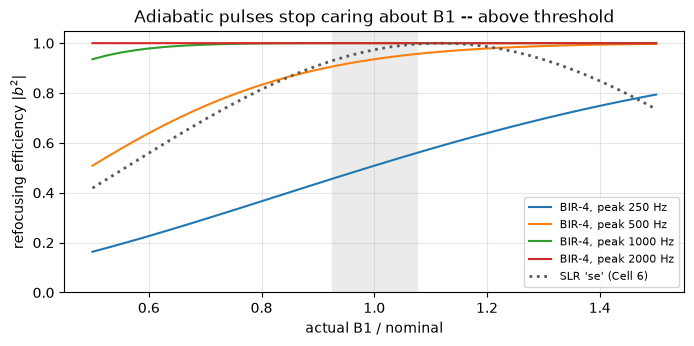

In [9]:
%matplotlib inline

# Cell 7 — BIR-4 adiabatic pulse and its threshold

print("Cell 7 — Adiabatic (BIR-4)")
print("--------------------------")

N_BIR, T_BIR = 1024, 4e-3
dt_bir = T_BIR / N_BIR

a_am, om = adiabatic.bir4(N_BIR, 10, np.arctan(20), np.pi, 40000 * np.pi)
rf_bir_shape = a_am * np.exp(1j * np.cumsum(om) * dt_bir)   # AM + FM -> complex waveform

peak_candidates = [250, 500, 1000, 2000]
curves = {}
print(f"  Duration {T_BIR*1e6:.0f} us, {N_BIR} samples. RF_MAX = {RF_MAX_HZ:.0f} Hz.\n")
print(f"  {'peak B1':>9s} {'feasible':>9s} " + "".join(f"{s:>7.1f}" for s in (0.6, 0.8, 1.0, 1.2, 1.4)))
print("  " + "-" * 54)

for peak_hz in peak_candidates:
    rf_bir = rf_bir_shape * (2 * np.pi * peak_hz * dt_bir)   # scale to a peak B1 in Hz
    eff = []
    for s in b1_scales:
        _, b_s = sim.abrm(rf_bir * s, centre_only)
        eff.append(np.abs(1j * b_s ** 2)[0])
    curves[peak_hz] = np.array(eff)
    shown = [curves[peak_hz][int(np.argmin(np.abs(b1_scales - s)))] for s in (0.6, 0.8, 1.0, 1.2, 1.4)]
    ok = "yes" if peak_hz <= RF_MAX_HZ else "NO"
    print(f"  {peak_hz:7d} Hz {ok:>9s} " + "".join(f"{v:7.2f}" for v in shown))

print()
print("Below the adiabatic threshold the pulse is amplitude-dependent like any other.")
print("Above it, the response is flat -- that flatness is the entire point.")

plt.figure(figsize=(8, 3.4))
for peak_hz, eff in curves.items():
    style = "-" if peak_hz <= RF_MAX_HZ else "--"
    plt.plot(b1_scales, eff, style, label=f"BIR-4, peak {peak_hz} Hz")
plt.plot(b1_scales, refocus_vs_b1, ":", color="0.35", lw=2, label="SLR 'se' (Cell 6)")
plt.fill_between(b1_scales, 0, 1.05, where=within10, color="0.92", zorder=0)
plt.xlabel("actual B1 / nominal"); plt.ylabel("refocusing efficiency $|b^2|$")
plt.title("Adiabatic pulses stop caring about B1 -- above threshold")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.ylim(0, 1.05)
plt.show()

## Cell 8 — Export a design MRI4ALL can play

A design is not finished until the scanner can run it. `pp.make_arbitrary_rf` takes the
waveform in **Hz** and a flip angle in radians, so reuse the Cell 2 conversions.

Two raster rules decide whether `check_timing()` passes, and both are easy to trip over:

- The sample interval `dt = duration / n_samples` must land on the **RF raster** (1 µs here).
  `128 samples over 1 ms` gives 7.8125 µs and fails; `128 × 10 µs = 1.28 ms` works.
- The ADC dwell must land on the **ADC raster** (100 ns). `128 samples over 2 ms` gives
  15.625 µs and fails; 2.56 ms gives 20 µs and works.

The saturation pulse is exported **with its spoiler**, because a saturation pulse without one
is just an excitation pulse — the magnetisation is in the transverse plane, not destroyed.

In [11]:
# Cell 8 — Write the designs to .seq

print("Cell 8 — Export to Pulseq")
print("-------------------------")

DT_RF = 10e-6                       # on the 1 us RF raster
PULSE_DURATION = N_SAMPLES * DT_RF

system = pp.Opts(
    max_grad=100, grad_unit="mT/m", max_slew=100, slew_unit="T/m/s",
    rf_raster_time=DT_RF, rf_dead_time=100e-6, rf_ringdown_time=20e-6,
    adc_dead_time=20e-6, block_duration_raster=1e-6,
)


def to_pulseq_rf(rf_waveform, duration_s, use):
    """PulPy waveform (rad/sample) -> a Pulseq RF event."""
    dt = duration_s / len(rf_waveform)
    signal_hz = np.real(rf_waveform) / (2 * np.pi * dt)
    flip_rad = float(np.real(np.sum(rf_waveform)))
    return pp.make_arbitrary_rf(
        signal=signal_hz.astype(complex), flip_angle=flip_rad,
        delay=system.rf_dead_time, system=system, use=use,
    ), signal_hz


seq = pp.Sequence(system)

# Saturation module: pulse + spoiler. Without the spoiler this is not saturation.
rf_sat_ev, sat_hz = to_pulseq_rf(rf_sat, PULSE_DURATION, "saturation")
spoiler = pp.make_trapezoid(channel="z", area=4 / 1e-3, duration=2e-3, system=system)
seq.add_block(rf_sat_ev)
seq.add_block(spoiler)

# Refocusing pulse
rf_se_ev, se_hz = to_pulseq_rf(rf_se, PULSE_DURATION, "refocusing")
seq.add_block(pp.make_delay(2e-3))
seq.add_block(rf_se_ev)

# A readout so the sequence is playable end to end
seq.add_block(pp.make_delay(2e-3))
seq.add_block(pp.make_adc(num_samples=128, duration=2.56e-3,
                          delay=system.adc_dead_time, system=system))

ok, err = seq.check_timing()
print(f"  saturation  : peak {np.abs(sat_hz).max():7.1f} Hz, flip {flip_angle_deg(rf_sat):6.1f} deg")
print(f"  refocusing  : peak {np.abs(se_hz).max():7.1f} Hz, flip {flip_angle_deg(rf_se):6.1f} deg")
print(f"  pulse length: {PULSE_DURATION*1e6:.0f} us each")
print()
if ok:
    print("PASS: timing check passed.")
else:
    print("WARNING: timing check failed:")
    for e in err:
        print("   ", e)

seq_path = work_dir / "sat_and_refocus.seq"
seq.write(str(seq_path))
print(f"\nWrote {seq_path.name} ({seq_path.stat().st_size} bytes)")
print("Feed this to notebook 03's interpreter to see it as MaRCoS instructions.")

Cell 8 — Export to Pulseq
-------------------------
  saturation  : peak   901.5 Hz, flip   88.8 deg
  refocusing  : peak  2644.6 Hz, flip  161.3 deg
  pulse length: 1280 us each

PASS: timing check passed.

Wrote sat_and_refocus.seq (4708 bytes)
Feed this to notebook 03's interpreter to see it as MaRCoS instructions.


## Exercises

Work through these in the session. Each is a small edit and a rerun; the point is to *see*
the trade rather than take it on faith.

**1. Sharpen the saturation profile.** Raise `TB` from 4 to 8 in Cell 3. The transition band
narrows — measure how much, and read the new peak B1. Now find the shortest duration that
still fits under `RF_MAX`. That number is your real design limit.

**2. Refocusing versus inversion.** Cell 4 designs both. Compare `|b^2|` at the band edges,
not the centre. Which would you want in a multi-echo train, and why does the distinction get
worse with each echo?

**3. Find the breaking point.** In Cell 6, at what B1 error does the saturation pulse leave
10% residual Mz? Compare that with the tolerance the refocusing pulse has for the same 10%
efficiency loss. This is the number that tells you how good your RF calibration has to be.

**4. Cross the adiabatic threshold.** In Cell 7, narrow the `peak_candidates` around the point
where the curve goes flat. Then reduce `T_BIR` from 4 ms and find where the threshold rises
above `RF_MAX` — that is where adiabatic stops being affordable on this hardware.

**5. Design one to spec.** Saturate a band 2 kHz wide, leaving under 5% residual Mz across it,
tolerating ±15% B1 error, in under 3 ms, within `RF_MAX`. Decide whether SLR or adiabatic gets
you there — and if neither does, say which constraint you would relax and why.

**6. Play it.** Take the `.seq` from Cell 8 into notebook 03's interpreter and look at `tx0`.
Does the peak sit where the design said it would, as a fraction of DAC full scale?

## What to take away

- **Flip angle is not a pulse.** Duration, bandwidth, peak amplitude and B1 tolerance are all
  part of the specification, and they trade against each other.
- **Peak B1 scales as 1/duration**, and a 180° costs twice the amplitude of a 90° at equal
  length. `RF_MAX` turns that into a hard feasibility boundary — Cell 5 draws it.
- **Saturation has no margin.** It fails on both sides of nominal, and over-flipping inverts
  rather than saturates. It is worth pairing with a good RF calibration, or making adiabatic.
- **Refocusing is flatter near nominal** but compounds across an echo train.
- **Adiabatic pulses buy B1 immunity with time and energy**, and only above a threshold
  amplitude — verify you are above it rather than assuming.
- **A saturation pulse without a spoiler is just an excitation pulse.**